In [40]:
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"
mlflow.set_tracking_uri("../mlruns")
mlflow.set_experiment("pinn")

pi2 = 2*np.pi

Momentum and continuity
$$u_t + u\,u_x + v\,u_y = -p_x + \frac{1}{Re}\left(u_{xx} + u_{yy}\right)$$
$$v_t + u\,v_x + v\,v_y = -p_y + \frac{1}{Re}\left(v_{xx} + v_{yy}\right)$$
$$u_x + v_y = 0$$

Initial Conditions:
$$u(x,y,0) = \sin(x)\cos(y)$$
$$v(x,y,0) = -\cos(x)\sin(y)$$
$$p(x,y,0) = -\frac{1}{4}\left(\cos(2x) + \cos(2y)\right)$$

Boundry Conditions:
$$u(0,y,t) = u(2\pi,y,t)$$
$$u(x,0,t) = u(x,2\pi,t)$$
$$v(0,y,t) = v(2\pi,y,t)$$
$$v(x,0,t) = v(x,2\pi,t)$$
$$p(0,y,t) = p(2\pi,y,t)$$
$$p(x,0,t) = p(x,2\pi,t)$$

Domain:
$$x,y∈[0,2π],t∈[0,T]$$

In [2]:
x_f = np.random.uniform(0, pi2, 10000)
y_f = np.random.uniform(0, pi2, 10000)
t_f = np.random.uniform(0, 1, 10000)
x_i = np.random.uniform(0, pi2, 2000)
y_i = np.random.uniform(0, pi2, 2000)
t_i = np.zeros_like(x_i)
u_i = np.sin(x_i) * np.cos(y_i)
v_i = -np.cos(x_i) * np.sin(y_i)
p_i = -1/4 * (np.cos(2 * x_i) + np.cos(2 * y_i))
t_b_x = np.random.uniform(0, 1, 1000)
x_b_l = np.zeros_like(t_b_x)
x_b_r = pi2 * np.ones_like(t_b_x)
y_b_x = np.random.uniform(0, pi2, 1000)
t_b_y = np.random.uniform(0, 1, 1000)
x_b_y = np.random.uniform(0, pi2, 1000)
y_b_b = np.zeros_like(t_b_y)
y_b_u = pi2 * np.ones_like(t_b_y)

In [5]:
def calculate_grad(f: torch.Tensor, x: torch.Tensor, retain_graph: bool = True) -> torch.Tensor:
    return  torch.autograd.grad(
            f, x,
            grad_outputs=torch.ones_like(f),
            retain_graph=retain_graph,
            create_graph=True
        )[0]

In [6]:
class NavierStokesPINN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.register_buffer("pi", torch.tensor(torch.pi))
        self.register_buffer("T", torch.tensor(1.0))
        self.register_buffer("nu", torch.tensor(1.0 / 10))
        self.input = nn.Sequential(
            nn.Linear(3, 50),
            nn.Tanh()
        )

        hidden_layers = []
        for _ in range(8):
            hidden_layers.append(nn.Linear(50, 50))
            hidden_layers.append(nn.Tanh())
        self.hidden = nn.Sequential(*hidden_layers)

        self.output = nn.Sequential(
            nn.Linear(50, 3),
        )

    def forward(self, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        x_n = (x - self.pi) / self.pi
        y_n = (y - self.pi) / self.pi
        t_n = t / self.T
        h = self.input(torch.cat([x_n, y_n, t_n], dim=1))
        h = self.hidden(h)
        out = self.output(h)
        return out
    
    def pde_residual(
            self,
            x: torch.Tensor,
            y: torch.Tensor,
            t: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        out = self.forward(x, y, t)
        u, v, p = torch.split(out, 1, dim=1)

        u_t = calculate_grad(u, t)
        u_x = calculate_grad(u, x)
        u_y = calculate_grad(u, y)
        u_xx = calculate_grad(u_x, x)
        u_yy = calculate_grad(u_y, y)
        p_x = calculate_grad(p, x)
        res_u = u_t + u*u_x + v*u_y + p_x - self.nu*(u_xx + u_yy)

        v_t = calculate_grad(v, t)
        v_x = calculate_grad(v, x)
        v_y = calculate_grad(v, y)
        v_xx = calculate_grad(v_x, x)
        v_yy = calculate_grad(v_y, y)
        p_y = calculate_grad(p, y)
        res_v = v_t + u*v_x + v*v_y + p_y - self.nu*(v_xx + v_yy)

        res_c = u_x + v_y

        return res_u, res_v, res_c


class MLflowCallback:
    def __init__(self) -> None:
        pass
    
    def on_epoch_end(self, epoch: int, losses_dict: dict[str, float]) -> None:
        for name, value in losses_dict.items():
            mlflow.log_metric(name, value, step=epoch)

    def log_params(self, params_dict: dict[str, int | float]) -> None:
        for name, value in params_dict.items():
            mlflow.log_param(name, value)

In [7]:
model = NavierStokesPINN().to(device)
criterion = nn.MSELoss()
lr = 1e-3
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=100, 
    min_lr=1e-6
)
epochs = 2000

In [8]:
x_f = torch.tensor(x_f, dtype=torch.float32, requires_grad=True).reshape(-1, 1).to(device)
y_f = torch.tensor(y_f, dtype=torch.float32, requires_grad=True).reshape(-1, 1).to(device)
t_f = torch.tensor(t_f, dtype=torch.float32, requires_grad=True).reshape(-1, 1).to(device)
x_i = torch.tensor(x_i, dtype=torch.float32).reshape(-1, 1).to(device)
y_i = torch.tensor(y_i, dtype=torch.float32).reshape(-1, 1).to(device)
t_i = torch.tensor(t_i, dtype=torch.float32).reshape(-1, 1).to(device)
u_i = torch.tensor(u_i, dtype=torch.float32).reshape(-1, 1).to(device)
v_i = torch.tensor(v_i, dtype=torch.float32).reshape(-1, 1).to(device)
p_i = torch.tensor(p_i, dtype=torch.float32).reshape(-1, 1).to(device)
t_b_x = torch.tensor(t_b_x, dtype=torch.float32).reshape(-1, 1).to(device)
x_b_l = torch.tensor(x_b_l, dtype=torch.float32).reshape(-1, 1).to(device)
x_b_r = torch.tensor(x_b_r, dtype=torch.float32).reshape(-1, 1).to(device)
y_b_x = torch.tensor(y_b_x, dtype=torch.float32).reshape(-1, 1).to(device)
t_b_y = torch.tensor(t_b_y, dtype=torch.float32).reshape(-1, 1).to(device)
x_b_y = torch.tensor(x_b_y, dtype=torch.float32).reshape(-1, 1).to(device)
y_b_b = torch.tensor(y_b_b, dtype=torch.float32).reshape(-1, 1).to(device)
y_b_u = torch.tensor(y_b_u, dtype=torch.float32).reshape(-1, 1).to(device)

In [42]:
with mlflow.start_run():
    callback = MLflowCallback()
    params = {
        "lr": 1e-3,
        "epochs": epochs,
    }
    callback.log_params(params)
    for epoch in range(epochs):
        optimizer.zero_grad()
        pred_ic = model(x_i, y_i, t_i)
        pred_ui, pred_vi, pred_pi = torch.split(pred_ic, 1, dim=1)
        loss_ic = (
            criterion(pred_ui, u_i)
            + criterion(pred_vi, v_i)
            + criterion(pred_pi, p_i)
        )

        pred_b_l = model(x_b_l, y_b_x, t_b_x)
        pred_b_r = model(x_b_r, y_b_x, t_b_x)
        pred_b_b = model(x_b_y, y_b_b, t_b_y)
        pred_b_u = model(x_b_y, y_b_u, t_b_y)
        loss_bc = (
            criterion(pred_b_l, pred_b_r)
            + criterion(pred_b_b, pred_b_u)
        )

        res_u, res_v, res_c = model.pde_residual(x_f, y_f, t_f)
        loss_pde = torch.mean(res_u**2 + res_v**2 + res_c**2)

        loss = 50*loss_ic + 10*loss_bc + loss_pde
        losses = {
            "loss_ic": loss_ic.item(),
            "loss_bc": loss_bc.item(),
            "loss_pde": loss_pde.item(),
            "loss": loss.item(),
        }
        callback.on_epoch_end(epoch, losses)
        callback.on_epoch_end(epoch, {"learning_rate": lr})
        loss.backward()
        optimizer.step()
        
        scheduler.step(loss_pde.item())


Solution:
$$u(x,y,t) = \sin(x)\cos(y)\,e^{-2t/Re}$$
$$v(x,y,t) = -\cos(x)\sin(y)\,e^{-2t/Re}$$
$$p(x,y,t) = -\frac{1}{4}\left(\cos(2x)+\cos(2y)\right)e^{-4t/Re}$$

In [49]:
def eval(t: float = 0) -> None: 
    x = np.linspace(0, pi2, 100)
    y = np.linspace(0, pi2, 100)
    x_mesh, y_mesh= np.meshgrid(x, y)
    t_mesh = t * np.ones_like(x_mesh)

    x_t = torch.tensor(x_mesh.reshape(-1, 1), dtype=torch.float32).to(device)
    y_t = torch.tensor(y_mesh.reshape(-1, 1), dtype=torch.float32).to(device)
    t_t = torch.tensor(t_mesh.reshape(-1, 1), dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pred = model(x_t, y_t, t_t)
        u_pred, v_pred, p_pred = torch.split(pred, 1, dim=1)

    Re = 10
    u_exact = np.sin(x_mesh)*np.cos(y_mesh)*np.exp(-2*t_mesh/Re)
    v_exact = -np.cos(x_mesh)*np.sin(y_mesh)*np.exp(-2*t_mesh/Re)
    p_exact = -0.25*(np.cos(2*x_mesh)+np.cos(2*y_mesh))*np.exp(-4*t_mesh/Re)

    u_exact = torch.tensor(u_exact.reshape(-1,1), dtype=torch.float32).to(device)
    v_exact = torch.tensor(v_exact.reshape(-1,1), dtype=torch.float32).to(device)
    p_exact = torch.tensor(p_exact.reshape(-1,1), dtype=torch.float32).to(device)

    def l2_relative(pred, exact):
        return torch.norm(pred - exact) / torch.norm(exact)

    err_u = l2_relative(u_pred, u_exact).item()
    err_v = l2_relative(v_pred, v_exact).item()
    err_p = l2_relative(p_pred, p_exact).item()

    print(f"For t = {t}")
    print(f"L2 relative error u: {err_u:.3}")
    print(f"L2 relative error v: {err_v:.3}")
    print(f"L2 relative error p: {err_p:.3}")

    x_f_eval = x_t.clone().detach().requires_grad_(True)
    y_f_eval = y_t.clone().detach().requires_grad_(True)
    t_f_eval = t_t.clone().detach().requires_grad_(True)

    res_u, res_v, res_c = model.pde_residual(x_f_eval, y_f_eval, t_f_eval)

    pde_error = torch.mean(res_u**2 + res_v**2 + res_c**2).item()
    print(f"PDE residual (MSE): {pde_error:.3}")


    err_u_local = torch.abs(u_pred - u_exact)
    err_v_local = torch.abs(v_pred - v_exact)
    err_p_local = torch.abs(p_pred - p_exact)
    err_u_map = err_u_local.cpu().numpy().reshape(100, 100)
    err_v_map = err_v_local.cpu().numpy().reshape(100, 100)
    err_p_map = err_p_local.cpu().numpy().reshape(100, 100)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    c0 = axes[0].contourf(x_mesh, y_mesh, err_u_map, 50)
    fig.colorbar(c0, ax=axes[0])
    axes[0].set_title(r"Local error $|u - u_{exact}|$")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    c1 = axes[1].contourf(x_mesh, y_mesh, err_v_map, 50)
    fig.colorbar(c1, ax=axes[1])
    axes[1].set_title(r"Local error $|v - v_{exact}|$")
    axes[1].set_xlabel("x")

    c2 = axes[2].contourf(x_mesh, y_mesh, err_p_map, 50)
    fig.colorbar(c2, ax=axes[2])
    axes[2].set_title(r"Local error $|p - p_{exact}|$")
    axes[2].set_xlabel("x")

    plt.show()

For t = 0
L2 relative error u: 0.131
L2 relative error v: 0.125
L2 relative error p: 0.979
PDE residual (MSE): 0.305


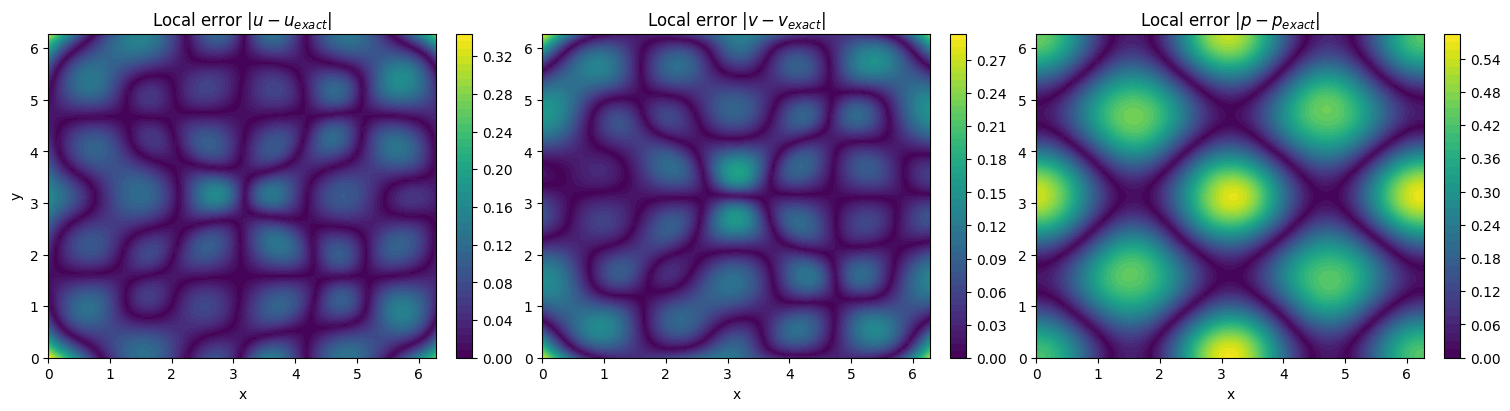

In [50]:
eval(0)

For t = 0.5
L2 relative error u: 0.161
L2 relative error v: 0.161
L2 relative error p: 0.979
PDE residual (MSE): 0.204


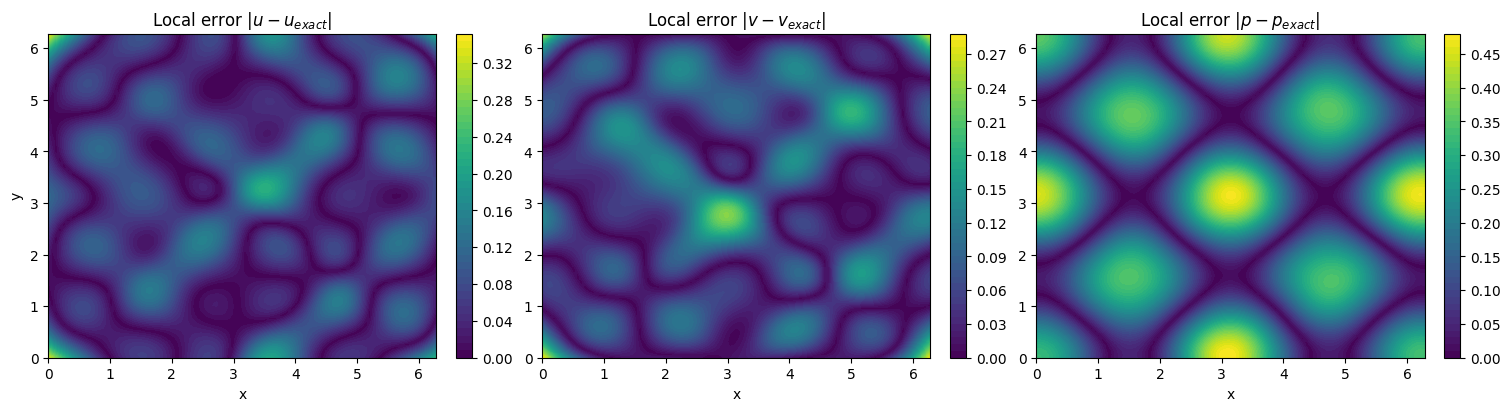

In [51]:
eval(0.5)

For t = 1
L2 relative error u: 0.188
L2 relative error v: 0.219
L2 relative error p: 0.98
PDE residual (MSE): 0.145


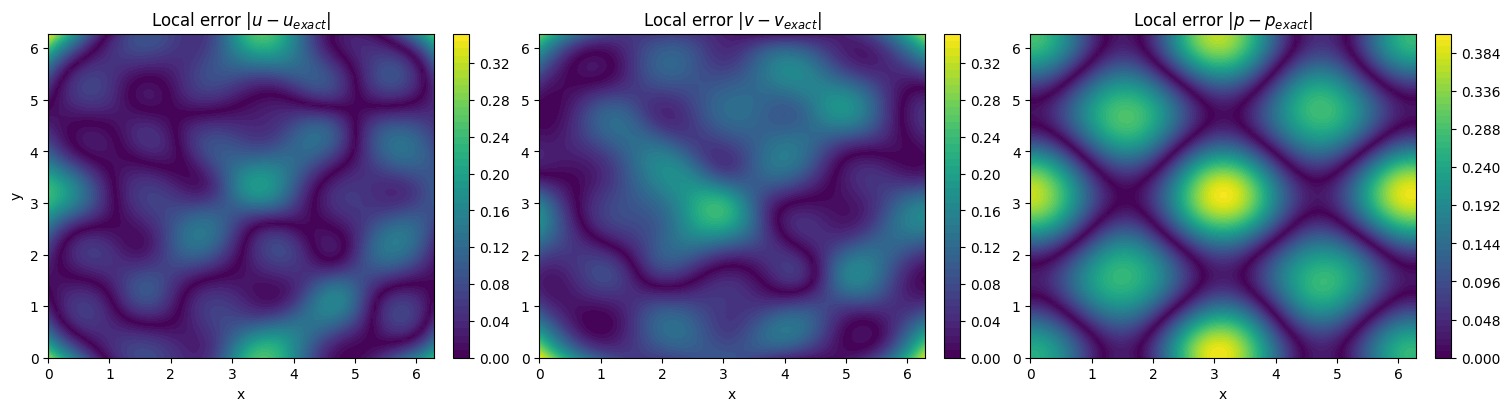

In [52]:
eval(1)